# 06 — Ablation Study

**The central research experiment.** It measures what each layer of GreenTruth's evidence
stack actually contributes.

## This is not an accuracy ablation, and that is deliberate

There is no adjudicated corpus of true/false flaring claims. Producing an accuracy table
would mean inventing the labels, which would make every number in it meaningless.

What *can* be measured honestly is how each layer changes the system's **behaviour**:
how often it finds compatible evidence, how wide its uncertainty is, how often it
declines to answer, and — the number that matters most — **how many confident-looking
verdicts the uncertainty layer prevents.**

## Configurations

| | adds |
|---|---|
| **A** text only | claim parsed into a structured record |
| **B** + geography | facility resolved to real coordinates |
| **C** + Earth observation | real flaring series retrieved |
| **D** + temporal | change measured across the window |
| **E** + uncertainty | bootstrap interval; **abstention becomes possible** |
| **F** full system | + methane, cross-scale, sufficiency, conflict, evidence ceiling |

The key contrast is **D vs E**. Configuration D issues a verdict from the point estimate
with nothing able to stop it — which is what a system without an uncertainty layer does.
E computes the interval and abstains when it spans materially different outcomes. The
difference between them is the measurable value of taking uncertainty seriously.

| Notebook card | |
|---|---|
| **Type** | Analyse (no training) |
| **Purpose** | Measure what each layer of the evidence stack changes in the system's behaviour (evidence availability, abstention, source disagreement). Not an accuracy ablation. |
| **Inputs** | The `greentruth` package and `data/real/`. Wraps `scripts/run_ablation.py`. |
| **Outputs** | `evaluation/ablation_results.json`. |
| **Where it runs** | Locally from a checkout, or Colab with the project folder available. |
| **Execution record** | Executed locally against the final code — record in `notebooks/executed/06_ablation_study.ipynb`. |


## 0. Setup

In [1]:
# ---------------------------------------------------------------- setup
# This notebook needs the GreenTruth package and the real data in data/real/.
# Nothing is uploaded by hand: if the repo is not present, the public flaring
# data is downloaded directly from the World Bank.
import os, sys, json, glob
from pathlib import Path

CANDIDATES = [".", "..", "/content", "/content/greentruth",
              "/content/drive/MyDrive/greentruth"]
REPO = None
for c in CANDIDATES:
    if os.path.isdir(os.path.join(c, "greentruth")):
        REPO = os.path.abspath(c)
        if REPO not in sys.path:
            sys.path.insert(0, REPO)
        break

if REPO is None:
    raise SystemExit(
        "GreenTruth package not found.\n"
        "Make it importable by ONE of:\n"
        "  * Colab Files panel -> upload the project folder\n"
        "  * from google.colab import drive; drive.mount('/content/drive')\n"
        "    with the project at /content/drive/MyDrive/greentruth\n"
        "  * run this notebook from inside a local checkout")

os.chdir(REPO)
print("repo:", REPO)

REAL = Path(REPO) / "data" / "real" / "flaring_by_field.csv"
if not REAL.exists():
    print("\ndata/real/flaring_by_field.csv missing -> run notebook 03 first.")
    print("It downloads the public World Bank release directly (no account).")
    raise SystemExit("real data not present")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from greentruth import GreenTruth

gt = GreenTruth(detector_preference="rule_based")
cov = gt.evidence.coverage()
print(f"\nreal evidence : {cov['n_observations']} annual observations, "
      f"{cov['n_fields']} fields, {cov['year_min']}-{cov['year_max']}")
print(f"methane       : {'loaded' if gt.methane.available else 'not loaded'}")
print(f"detector      : {gt.detector_info['detector']}"
      f"{' (fallback)' if gt.detector_info.get('fallback') else ''}")

repo: <local checkout>



real evidence : 156 annual observations, 12 fields, 2012-2024
methane       : loaded
detector      : rule_based (fallback)


In [2]:
# ------------------------------------------------- data provenance banner
# Printed before any analysis so a reader can see exactly what is loaded,
# where it came from, and under what licence — without leaving the notebook.
reg_path = Path(REPO) / "data" / "dataset_registry.json"
if reg_path.exists():
    reg = json.loads(reg_path.read_text(encoding="utf-8"))
    print("=" * 78)
    print("DATA PROVENANCE")
    print("=" * 78)
    for d in reg["datasets"]:
        ff = d.get("file_facts") or {}
        if not ff.get("present") and not d.get("n_test"):
            continue
        if d.get("role_in_greentruth") == "NOT USED":
            continue
        print(f"\nDATA SOURCE   {d['name']}")
        print(f"PROVIDER      {d['provider']}")
        print(f"INSTRUMENT    {d['instrument']}")
        print(f"URL           {d['official_url']}")
        print(f"LICENSE       {d['licence']}")
        print(f"RESOLUTION    {d['spatial_resolution']} | {d['temporal_resolution']}")
        if ff.get("present"):
            print(f"DATA SHAPE    {ff['rows']:,} rows x {len(ff['columns'])} cols "
                  f"| {ff['entities']} entities | {ff['year_min']}-{ff['year_max']}")
        elif d.get("n_test"):
            print(f"DATA SHAPE    test split n = {d['n_test']}")
        print(f"DATE ACCESSED {d['date_accessed']}  ({d['date_accessed_note']})")
        print(f"ROLE          {d['role_in_greentruth']}")
    print("\n" + "=" * 78)
    print(reg["independence_rule"])
    print("=" * 78)
else:
    print("data/dataset_registry.json not found — run "
          "scripts/build_dataset_registry.py to generate it.")

DATA PROVENANCE

DATA SOURCE   World Bank Global Gas Flaring Tracker — individual flare locations
PROVIDER      World Bank, Global Flaring and Methane Reduction (GFMR) Partnership
INSTRUMENT    VIIRS (Suomi-NPP / NOAA-20)
URL           https://www.worldbank.org/en/programs/gasflaringreduction/global-flaring-data
LICENSE       Published publicly by the World Bank. Check the portal terms before redistribution; this project does not commit the CSVs.
RESOLUTION    Individual flare detections; aggregated here to named fields by a per-field match radius (60–200 km) | annual
DATA SHAPE    156 rows x 4 cols | 12 entities | 2012-2024
DATE ACCESSED 2026-09-17  (local file timestamp, a proxy for when the pipeline notebook was run)
ROLE          PRIMARY EVIDENCE for gas-flaring claims

DATA SOURCE   World Bank Global Gas Flaring Tracker — country totals
PROVIDER      World Bank, Global Flaring and Methane Reduction (GFMR) Partnership
INSTRUMENT    VIIRS (Suomi-NPP / NOAA-20)
URL           https://

## 1. Run the ablation

This calls `scripts/run_ablation.py`, the same code that produced the committed results,
so the notebook and the repository cannot disagree.

In [3]:
import subprocess, sys as _s
proc = subprocess.run([_s.executable, "scripts/run_ablation.py"],
                      capture_output=True, text=True, cwd=REPO)
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print("STDERR:", proc.stderr[-2000:])

ab = json.loads((Path(REPO) / "evaluation" / "ablation_results.json")
                .read_text())["summary"]
print("\nprobe claims:", ab["n_probe_claims"], "across", ab["n_fields"], "real fields")

518 probe claims across 12 real fields

  100/518
  200/518
  300/518
  400/518
  500/518

ABLATION â€” measured system properties (NOT accuracy)
518 probe claims across 12 real fields

A â€” text only
   adds: claim parsed into a structured record
   claims_parsed                          1.0
   fully_specified                        1.0
   mean_slot_coverage                     1.0
   can_assess_against_evidence            0.0
   note: No evidence is consulted, so nothing can be assessed physically.

B â€” + geographic context
   adds: facility resolved to real coordinates
   facility_resolved                      1.0
   has_coordinates                        1.0
   can_assess_against_evidence            0.0
   note: A location is now known, but no observation has been retrieved.

C â€” + Earth observation
   adds: real flaring series retrieved
   evidence_available                     1.0
   mean_observations_per_field            13.0
   can_assess_against_evidence            1.0
  

## 2. The configuration table

In [4]:
rows = []
for key, c_ in ab["configurations"].items():
    rows.append(dict(
        config=c_["name"],
        adds=c_["adds"],
        can_assess=c_.get("can_assess_against_evidence"),
        abstention=c_.get("abstention_rate"),
        median_width=c_.get("median_interval_width"),
        prevented=c_.get("unsupported_verdicts_prevented")))
print(pd.DataFrame(rows).to_string(index=False))

h = ab["headline"]
print("\n" + "=" * 74)
print("HEADLINE")
print("=" * 74)
print(f"  verdicts a point estimate would issue : {h['of_verdicts_a_point_estimate_would_issue']}")
print(f"  prevented by the uncertainty layer    : {h['unsupported_verdicts_prevented']} "
      f"({h['prevention_rate']:.1%})")
print(f"  overall abstention rate               : {h['abstention_rate']:.1%}")
print(f"  cross-source disagreement rate        : {h['cross_source_disagreement_rate']:.1%}")

                  config                                                          adds  can_assess  abstention  median_width  prevented
           A — text only                         claim parsed into a structured record         0.0         NaN           NaN        NaN
B — + geographic context                         facility resolved to real coordinates         0.0         NaN           NaN        NaN
 C — + Earth observation                                 real flaring series retrieved         1.0         NaN           NaN        NaN
 D — + temporal analysis                       change measured across the claim window         NaN       0.000           NaN        NaN
       E — + uncertainty               bootstrap interval; abstention becomes possible         NaN       0.917        0.7541      475.0
         F — full system methane, cross-scale, sufficiency, conflict, evidence ceiling         NaN       0.917           NaN        NaN

HEADLINE
  verdicts a point estimate would issu

## 3. Abstention is not uniform

A 3-year window on a noisy annual series is mostly noise; a decade of change is not.
Breaking the abstention rate down by window length turns "the system abstains a lot" into
something actionable: it tells a user what length of claim this evidence can settle.

 window_years   n  abstention_rate  median_interval_width
            3 101           0.9505                 0.8051
            4  85           0.9294                 0.7928
            5  78           0.9744                 0.8106
            6  64           0.9688                 0.7617
            7  51           0.9608                 0.7367
            8  49           0.9184                 0.7328
            9  38           0.7368                 0.6885
           10  25           0.7600                 0.6080
           11  17           0.7647                 0.6035
           12  10           0.8000                 0.6213


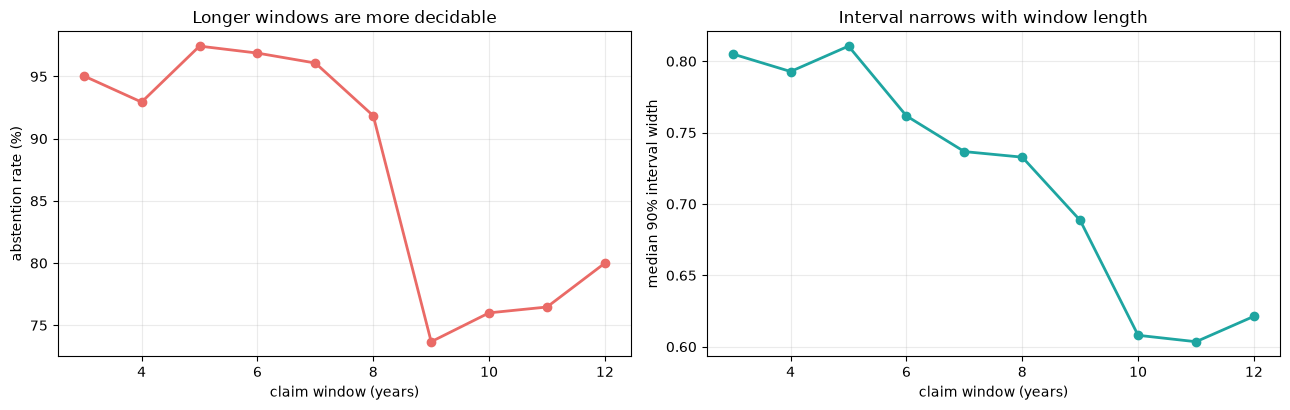

In [5]:
w = ab["abstention_by_window_length"]
wdf = pd.DataFrame([dict(window_years=int(k), n=v["n"],
                         abstention_rate=v["abstention_rate"],
                         median_interval_width=v["median_interval_width"])
                    for k, v in w.items()]).sort_values("window_years")
print(wdf.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].plot(wdf.window_years, wdf.abstention_rate * 100, "o-", color="#ea6a66", lw=2)
ax[0].set_xlabel("claim window (years)"); ax[0].set_ylabel("abstention rate (%)")
ax[0].set_title("Longer windows are more decidable"); ax[0].grid(alpha=.25)
ax[1].plot(wdf.window_years, wdf.median_interval_width, "o-", color="#1ea5a1", lw=2)
ax[1].set_xlabel("claim window (years)"); ax[1].set_ylabel("median 90% interval width")
ax[1].set_title("Interval narrows with window length"); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

## 4. Cross-source behaviour (configuration F only)

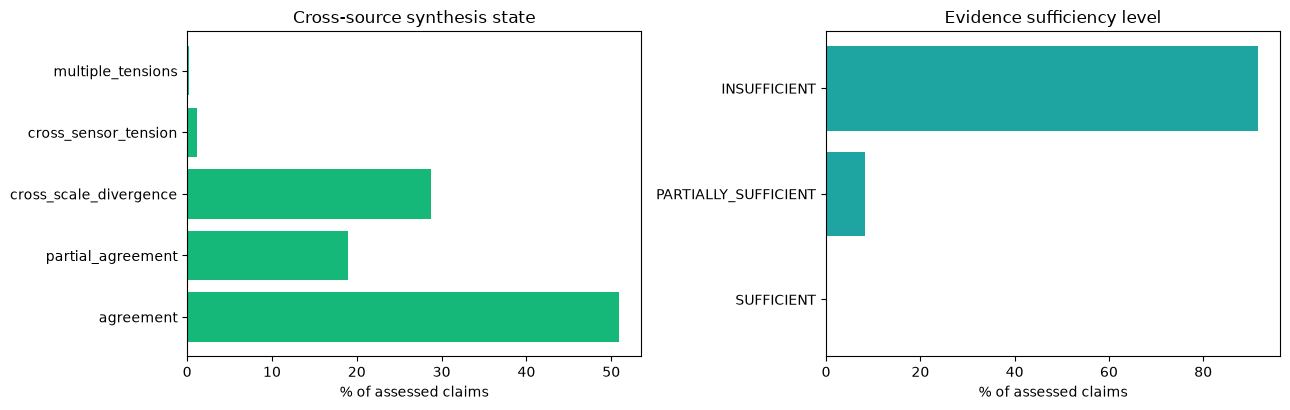

independent instrument available : 8.1%
cross-source disagreement        : 30.1%

NOTE on the low methane rate: most probe windows start before 2019, and
Sentinel-5P begins in 2019. The independent instrument is unavailable for
those windows by construction, not because the data is missing.


In [6]:
F = ab["configurations"]["F_full_system"]
st = F["synthesis_states"]
lv = F["sufficiency_levels"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
k = [x for x in st if st[x]]; v = [st[x] * 100 for x in k]
ax[0].barh(k, v, color="#15b879")
ax[0].set_xlabel("% of assessed claims"); ax[0].set_title("Cross-source synthesis state")
k2 = list(lv); v2 = [lv[x] * 100 for x in k2]
ax[1].barh(k2, v2, color="#1ea5a1")
ax[1].set_xlabel("% of assessed claims"); ax[1].set_title("Evidence sufficiency level")
plt.tight_layout(); plt.show()

print(f"independent instrument available : {F['independent_instrument_rate']:.1%}")
print(f"cross-source disagreement        : {F['cross_source_disagreement_rate']:.1%}")
print()
print("NOTE on the low methane rate: most probe windows start before 2019, and")
print("Sentinel-5P begins in 2019. The independent instrument is unavailable for")
print("those windows by construction, not because the data is missing.")

## 5. What this does and does not show

**Shows, measured:**

* every layer up to D can only ever *issue* verdicts — none can decline;
* the uncertainty layer prevents a large majority of the verdicts a point estimate would
  have produced on this data;
* decidability depends strongly on window length;
* independent sources disagree often enough that treating one as definitive would be
  unsafe.

**Does not show:** whether any verdict is *correct*. No accuracy is reported, because no
ground truth exists. The integrity block saved with the results records this.

In [7]:
print(json.dumps(ab["integrity"], indent=2))

{
  "ground_truth_available": false,
  "accuracy_reported": false,
  "why": "No adjudicated corpus of true/false flaring claims exists. This ablation measures system behaviour \u2014 evidence availability, uncertainty width, abstention, cross-source agreement \u2014 and deliberately reports no accuracy metric.",
  "probe_claims": "Claims are constructed from real observed windows to exercise the pipeline uniformly. They are probes, not corporate claims. All observations are real."
}
